### Import dependencies

In [16]:
import torch
from pyprojroot import here
import matplotlib.pyplot as plt
import torchvision.io as io
from torchvision.utils import save_image
import kornia.augmentation as K

### Define Kornia augmentation

In [17]:
aug = torch.nn.Sequential(
    K.RandomResizedCrop((224, 224), scale=(0.9, 1.0), same_on_batch=True),
    K.RandomHorizontalFlip(p=0.5, same_on_batch=True),
    K.ColorJitter(0.1, 0.1, 0.1, 0.0, same_on_batch=True),
    K.RandomGaussianBlur((3, 3), (0.1, 1.0), p=1.0, same_on_batch=True),
)

###  Load all images from one video folder

In [18]:
input_folder = here("dataset/msvd-images/val/b_BuSVZwq6M_1_9")
output_folder = here("notebook/videos_aug/video_01/")
output_folder.mkdir(parents=True, exist_ok=True)

In [ ]:
# Collect all image file names
image_files = sorted(input_folder.glob('*'))

### Read each image and stack into [T,C,H,W]

In [ ]:
frames = []
for image_path in image_files:
    img = io.read_image(image_path).float() / 255.0  # [C,H,W], [0,1]
    frames.append(img)
frames = torch.stack(frames, dim=0)  # [T,C,H,W]
print("Loaded frames:", frames.shape)

Loaded frames: torch.Size([128, 3, 224, 224])


### Apply augmentation (same for all frames)

In [22]:
aug_frames = aug(frames)
print("Augmented frames:", aug_frames.shape)

Augmented frames: torch.Size([128, 3, 224, 224])


### Save augmented frames

In [23]:
for i, fname in enumerate(image_files):
    save_path = output_folder / fname.name
    save_image(aug_frames[i], save_path)

print(f"Saved {len(image_files)} augmented frames to {output_folder}")

Saved 128 augmented frames to /home/yato/ML/video_captioning/VideoCaptioning/notebook/videos_aug/video_01


### Plot images

In [30]:
img1 = frames[0].permute(1, 2, 0)  # [H,W,C]
img2 = aug_frames[0].permute(1, 2, 0)

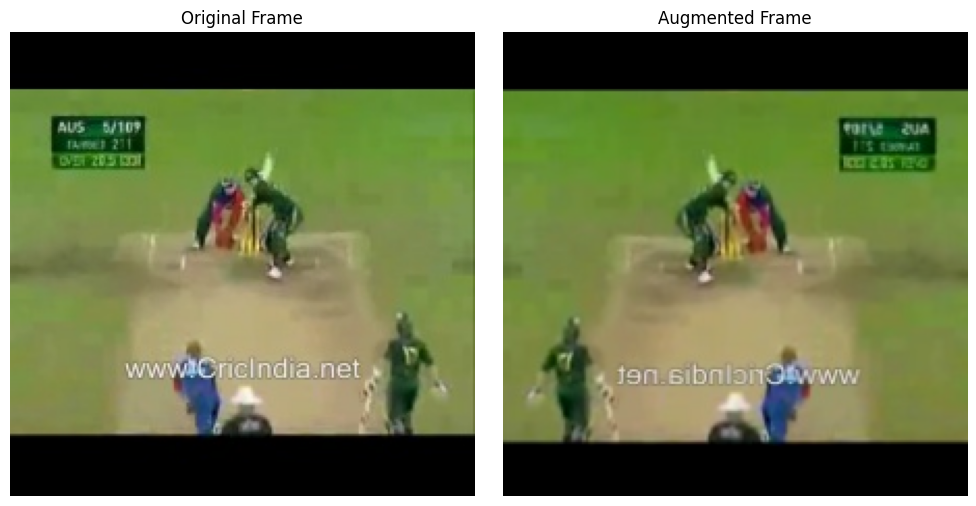

In [31]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img1)
plt.title("Original Frame")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img2)
plt.title("Augmented Frame")
plt.axis("off")

plt.tight_layout()
plt.show()